In [1]:
import pandas as pd
import matplotlib.pyplot as plt

optimized = pd.read_csv(
    "../data/processed/optimized_slot_recommendations.csv"
)

business = pd.read_csv(
    "../data/processed/business_insights.csv"
)

summary = pd.read_csv(
    "../data/processed/optimization_summary.csv"
)

evaluation = pd.read_csv(
    "../data/processed/before_after_evaluation.csv"
)

print(optimized.shape)
print(summary)

(2370, 17)
                    Metric       Value
0  Average Before Distance  102.943593
1   Average After Distance    3.939385
2   Average Distance Saved   99.004208
3            Improvement %   96.173259
4       Products Relocated   25.000000


cluster_name
Active/Regular Products    2192
High-Volume Products        178
Name: count, dtype: int64


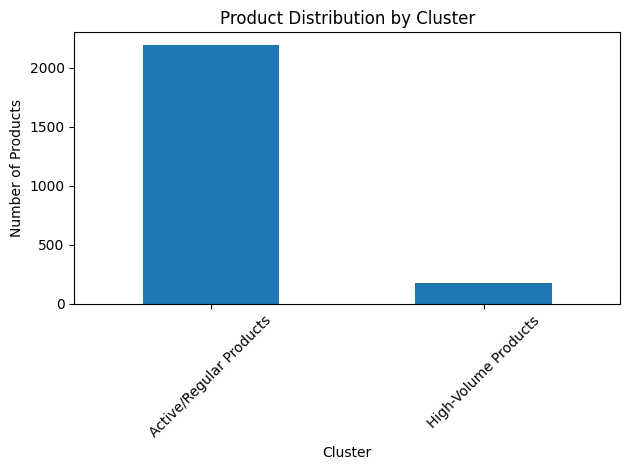

In [2]:
cluster_counts = optimized["cluster_name"].value_counts()

print(cluster_counts)

cluster_counts.plot(kind="bar")

plt.title("Product Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

recommended_zone
Zone B    2192
Zone A     178
Name: count, dtype: int64


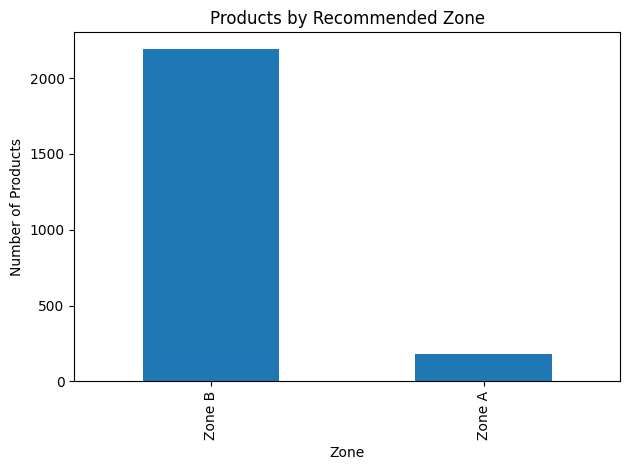

In [3]:
zone_counts = optimized["recommended_zone"].value_counts()

print(zone_counts)

zone_counts.plot(kind="bar")

plt.title("Products by Recommended Zone")
plt.xlabel("Zone")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

In [5]:
top_savings = optimized.sort_values(
    "actual_distance_saved",
    ascending=False
).head(10)

print(
    top_savings[
        [
            "StockCode",
            "cluster_name",
            "recommended_zone",
            "actual_distance_saved"
        ]
    ]
)

   StockCode          cluster_name recommended_zone  actual_distance_saved
0      23309  High-Volume Products           Zone A                   60.0
1      22086  High-Volume Products           Zone A                   59.0
5      22998  High-Volume Products           Zone A                   59.0
6      22616  High-Volume Products           Zone A                   58.0
2     85123A  High-Volume Products           Zone A                   58.0
10     17003  High-Volume Products           Zone A                   58.0
7      15036  High-Volume Products           Zone A                   57.0
11     71459  High-Volume Products           Zone A                   57.0
3      22577  High-Volume Products           Zone A                   57.0
15     21231  High-Volume Products           Zone A                   57.0


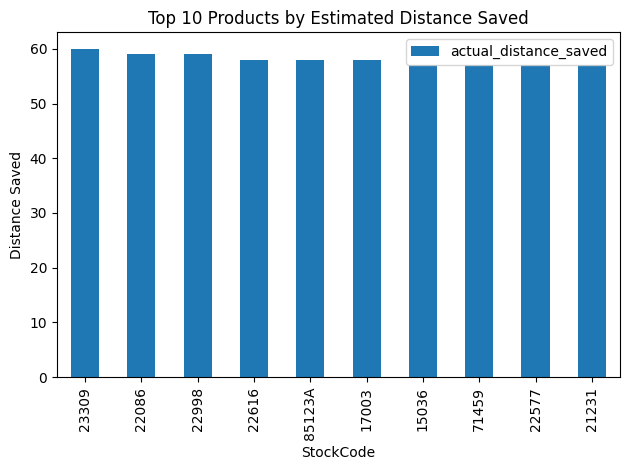

In [6]:
top_savings.plot(
    x="StockCode",
    y="actual_distance_saved",
    kind="bar"
)

plt.title("Top 10 Products by Estimated Distance Saved")
plt.xlabel("StockCode")
plt.ylabel("Distance Saved")
plt.tight_layout()
plt.show()

In [7]:
before = summary.loc[
    summary["Metric"] == "Average Before Distance",
    "Value"
].iloc[0]

after = summary.loc[
    summary["Metric"] == "Average After Distance",
    "Value"
].iloc[0]

print("Before:", before)
print("After:", after)

Before: 102.94359282637012
After: 3.939384831179241


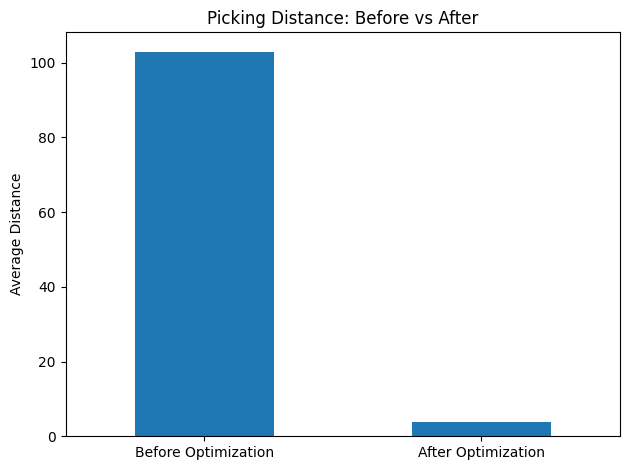

In [8]:
comparison = pd.Series(
    [before, after],
    index=["Before Optimization", "After Optimization"]
)

comparison.plot(kind="bar")

plt.title("Picking Distance: Before vs After")
plt.ylabel("Average Distance")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
print("========== FINAL PROJECT RESULTS ==========")

print("Products Analyzed:", len(optimized))

print("Total Estimated Distance Saved:",
      optimized["actual_distance_saved"].sum())

print("Average Distance Saved:",
      optimized["actual_distance_saved"].mean())

print("Average Before Distance:", before)

print("Average After Distance:", after)

========== FINAL PROJECT RESULTS ==========
Products Analyzed: 2370
Total Estimated Distance Saved: 1400.0
Average Distance Saved: 56.0
Average Before Distance: 102.94359282637012
Average After Distance: 3.939384831179241


In [10]:
final_report = pd.DataFrame({
    "Metric": [
        "Products Analyzed",
        "Total Estimated Distance Saved",
        "Average Distance Saved",
        "Average Before Distance",
        "Average After Distance"
    ],
    "Value": [
        len(optimized),
        optimized["actual_distance_saved"].sum(),
        optimized["actual_distance_saved"].mean(),
        before,
        after
    ]
})

final_report.to_csv(
    "../data/processed/final_project_metrics.csv",
    index=False
)